In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from Bootstraping import *
from sklearn.model_selection import train_test_split
import torch.nn.functional as F

# defining models

In [6]:
class ReadoutNet(nn.Module):
    def __init__(self,bins):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(9*bins, 12),
            nn.ReLU(),
            nn.Linear(12,4)
        )

    def forward(self, x):
        # x: (batch, 4, 300)
        x = x.view(x.shape[0], -1)

        logits = self.net(x)
        pred = torch.argmax(logits, dim=1)

        return logits, pred
    
    
class SmallReadoutCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(4, 24, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),      # (batch, 24, 1) -> (batch, 24)
            nn.Linear(24, 24),
            nn.ReLU(),
            nn.Linear(24, 4)
        )

    def forward(self, x):
        x = self.features(x)
        logits = self.classifier(x)
        pred = torch.argmax(logits, dim=1)
        return logits, pred


class CNN(nn.Module):
    def __init__(self):
        super().__init__()


        # Input: 4 readout frequencies, 500 time steps
        self.conv1 = nn.Conv1d(4, 500, kernel_size=9, padding=4)   # small first layer
        self.pool1 = nn.AvgPool1d(kernel_size=2)                  # 500 -> 250

        self.conv2 = nn.Conv1d(500, 64, kernel_size=9, padding=4) # moderate second layer
        self.pool2 = nn.AvgPool1d(kernel_size=2)                  # 250 -> 125

        # Optional third conv for richer features
        self.conv3 = nn.Conv1d(64, 32, kernel_size=9, padding=4)

        # Global average pooling over time dimension
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # Fully connected layer to classify into n_classes
        self.fc = nn.Linear(32, 16)
        
        self.fc2 = nn.Linear(16, 4)

    def forward(self, x):
        # x: (batch_size, 4, 500)

        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))

        x = self.global_pool(x)   # (batch_size, 32, 1)
        x = x.squeeze(-1)         # (batch_size, 32)

        x = self.fc(x)    
        x = F.relu(x)# (batch_size, n_classes)
        x = self.fc2(x)            # (batch_size, n_classes)
        pred = torch.argmax(x, dim=1)

        return x,pred

class ReadoutCNN_bigger(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(4, 32, kernel_size=10, padding=5)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=9, padding=4)

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 4)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))

        x = self.pool(x).squeeze(-1)

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        logits = self.fc3(x)
        pred = torch.argmax(logits, dim=1)
        return logits, pred

# Defining DataSet Structure

In [7]:


class ReadoutDataset_estimator_(Dataset):
    def __init__(self, X, Y):
        denom = torch.arange(1, X.shape[-1] + 1, dtype=torch.float32).view(1, 1, X.shape[-1])
        self.X = torch.tensor(X, dtype=torch.float32)/ denom
        x = self.X
        std = x.std(dim=(0, 2), keepdim=True)
        self.X = x/std
        self.X = x / (x.mean(dim=(1,2), keepdim=True) + 1e-8) 
        self.Y = torch.tensor(Y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]
    
    
    
class ReadoutDataset_Fancy_(Dataset):
    def __init__(self, X, Y,bin_size = 10):
        data = []
        for x in X:
            data.append(make_features(np.array(x),bin_size))
            
        self.X = torch.tensor(data,dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]
    
    

class ReadoutDataset_differential_(Dataset):
    def __init__(self, X, Y):
        denom = torch.arange(1, X.shape[-1] + 1, dtype=torch.float32).view(1, 1, X.shape[-1])
        dx = torch.tensor( X[:,0,:] + X[:,1,:] - X[:,2,:] - X[:,3,:])
        dy = torch.tensor( X[:,0,:] + X[:,2,:] - X[:,3,:] - X[:,1,:])
        
        self.X = torch.zeros((X.shape[0],2,X.shape[2]))      
        self.X[:,0,:] = dx
        self.X[:,1,:] = dy
        self.X = self.X/denom
        self.Y = torch.tensor(Y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [9]:
import numpy as np

values = [0, 1, 2]

def get_trace(
    nro,
    init_state=0,
    dark_rate=0.163,
    signal_rate=0.14,
    dark_sigma=0.002,
    signal_sigma=0.002,
    probs=np.array([1 - 1/300 - 1/3000, 1/300, 1/3000])
):
    # sample flips
    flips = np.random.choice(values, size=nro, p=probs)

    # sample Gaussian-distributed Poisson rates at each time step
    dark_K = np.random.normal(loc=dark_rate, scale=dark_sigma, size=(4, nro))
    signal_K = np.random.normal(loc=signal_rate, scale=signal_sigma, size=nro)

    # Poisson rates must be positive
    dark_K = np.clip(dark_K, 1e-9, None)
    signal_K = np.clip(signal_K, 1e-9, None)

    # now sample counts from Poisson with those time-dependent rates
    dark = np.random.poisson(dark_K)
    signal = np.random.poisson(signal_K)

    counts = dark.copy()
    s = init_state

    for t in range(nro):
        counts[s, t] += signal[t]

        f = flips[t]

        if f == 1:
            if s == 0:
                s = 1
            elif s == 1:
                s = 0
            elif s == 2:
                s = 3
            else:
                s = 2

        elif f == 2:
            if s == 0:
                s = 2
            elif s == 2:
                s = 0
            elif s == 1:
                s = 3
            else:
                s = 1

    return np.cumsum(counts, axis=1)

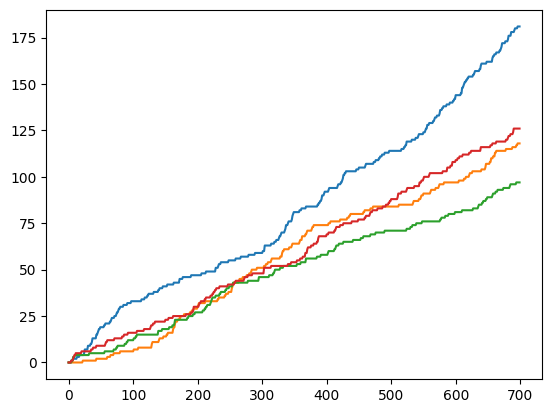

In [10]:
x = get_trace(700)

plt.plot(x[0])
plt.plot(x[1])
plt.plot(x[2])
plt.plot(x[3])
X_choosen = np.array([get_trace(300,init_state = k%4) for k in range(10000)])
Y_data = np.array([k%4 for k in range(10000)])


    

In [11]:
plt.plot(meas_counts[0,0,0])
plt.plot(meas_counts[0,0,1])
plt.plot(meas_counts[0,0,2])
plt.plot(meas_counts[0,0,3])



NameError: name 'meas_counts' is not defined

In [359]:

def save_model_with_accuracy(model, accuracy,name):
    filename = name + f"model_acc_{accuracy:.4f}.pt"
    torch.save(model.state_dict(), filename)
    print(f"saved {filename}")

# Load Measurement Data

In [12]:
names = ['20260313235440__NuclearReadout_With_tracking_XY_read_out.hdf5','20260313223620__NuclearReadout_With_tracking_XY_read_out.hdf5','20260313122250__NuclearReadout_With_tracking_XY_read_out.hdf5','20260314203749__NuclearReadout_With_tracking_XY_read_out.hdf5','20260316000131__NuclearReadout_With_tracking_XY_read_out.hdf5','20260324003123__NuclearReadout_With_tracking_XY_read_out.hdf5', '20260323214621__NuclearReadout_With_tracking_XY_read_out.hdf5',]

In [18]:

dirpath = 'Z:/SPIN-001/Run2 [BFp4]/NuclearReadout_With_tracking_XY_read_out/'
signal = load_h5_to_dic(dirpath + names[0])[0]



In [19]:
X_data = []
Y_data = []

for meas_id in range(len(names)-1):
    signal = load_h5_to_dic(dirpath + names[meas_id])[0]
    clicksX = signal['clicksX']
    print(signal['clicksX'].shape)
    clicks = clicksX[:,:,:,:]
    r = 500


    meas_counts = np.array([np.array([clicks[:,:,:nro,i].sum(-1) for nro in range(r)]) for i in range(4)])
    meas_counts = meas_counts.transpose(2,0, 1, 3)

    for i in range(4):
        X_data.extend(meas_counts[:,i,:,:])
        Y_data.extend(np.repeat(i,meas_counts.shape[0]))
        
     
X_data = np.array(X_data)
Y_data = np.array(Y_data)
X_data = X_data.transpose(0,2,1)


(2901, 4, 500, 4)
(180, 4, 500, 4)
(57, 4, 1500, 4)
(2801, 4, 500, 4)
(433, 4, 700, 4)
(255, 4, 500, 4)


In [ ]:
X_choosen.shape


(720, 4, 500)

clicks shape is  (26508, 4, 500)


IndexError: too many indices for array: array is 3-dimensional, but 4 were indexed

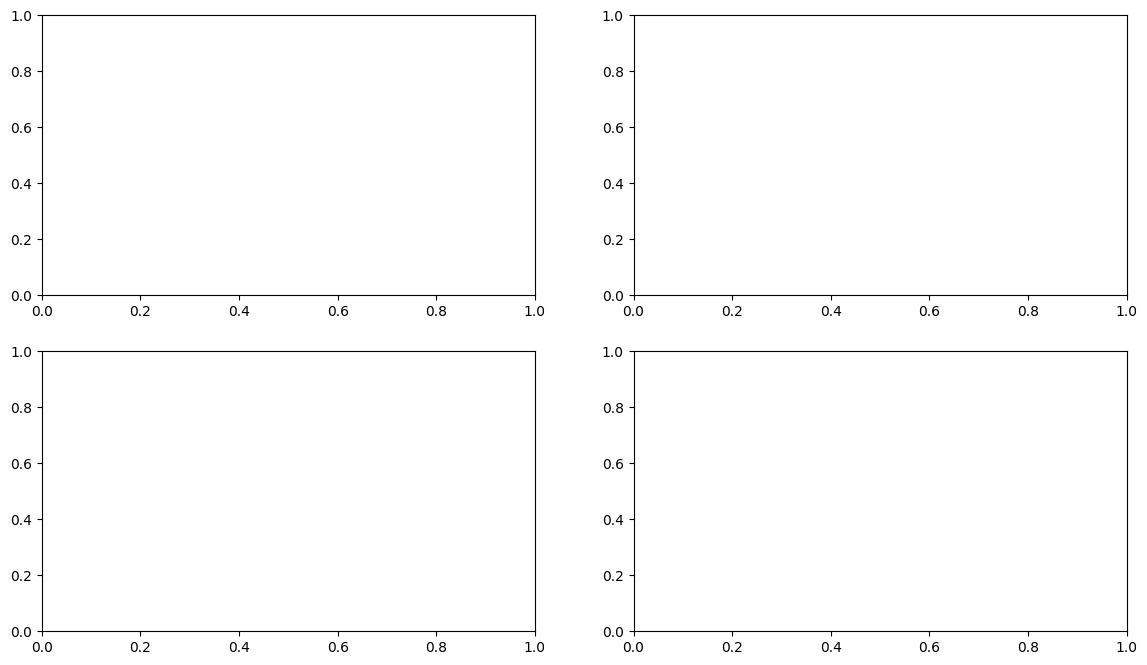

In [ ]:
nro_delta_x = 490
nro_delta_y = 100
figs = []



fig,ax = plt.subplots(2,2,figsize = (14,8))


clicksX = signal['clicksX']

nuclear_nro = clicksX.shape[2]



avg = clicksX.shape[0]
nb_prep_states = clicksX.shape[1]
xnro = clicksX.shape[2]

print('clicks shape is ',clicksX.shape)  #clicks shape is  (43, 4, 50, 4)

delta_X = np.zeros((nb_prep_states,avg))
delta_X_nro = np.zeros((nb_prep_states,avg,nuclear_nro))
delta_Y_nro = np.zeros((nb_prep_states,avg,nuclear_nro))
delta_Y = np.zeros((nb_prep_states,avg))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

buffer1 =[]
buffer2 =[]
for prepped_state in [0,1,2,3]:
    
    
    dx_nro = clicksX[:,prepped_state,:,0] + clicksX[:,prepped_state,:,1] - clicksX[:,prepped_state,:,2] - clicksX[:,prepped_state,:,3]
    dy_nro = clicksX[:,prepped_state,:,0] + clicksX[:,prepped_state,:,2] - clicksX[:,prepped_state,:,3] - clicksX[:,prepped_state,:,1]
    

    delta_X_nro[prepped_state] = dx_nro
    delta_Y_nro[prepped_state] = dy_nro
    
    delta_X[prepped_state] = dx_nro[:,:nro_delta_x].sum(1)
    delta_Y[prepped_state] = dy_nro[:,:nro_delta_y].sum(1)

    # delta_X[prepped_state,:] = np.where(np.abs(delta_X[prepped_state,:])>5,delta_X[prepped_state,:],0)
    # delta_Y[prepped_state,:] = np.where(np.abs(delta_Y[prepped_state,:])>5,delta_Y[prepped_state,:],0)

    ax[0,0].scatter(delta_X[prepped_state,:],delta_Y[prepped_state,:],label = f'state {prepped_state}',alpha = 0.2)
    

ax[0,0].set_xlabel('Delta X  = (0+1) - (2+3)')
ax[0,0].set_ylabel('Delta Y  = (0+2) - (1+3)')
ax[0,0].set_title(f'ReadOut Distribution for NRO_X = {nro_delta_x} and NRO_Y = {nro_delta_y}')
ax[0,0].legend()

states_points  = np.array([np.stack((delta_X[i], delta_Y[i]),axis= 1) for i in range(4)])
states_points_nro  = np.array([np.stack((delta_X_nro[i,:], delta_Y_nro[i,:]),axis= 1) for i in range(4)])
print("state points shape is ", states_points_nro.shape)
labels = np.zeros(states_points.shape[:2], dtype=int)-1
labels_nro = np.zeros(states_points.shape[:2], dtype=int)-1
fidelity = np.zeros((4,nuclear_nro))
for i, state  in enumerate(states_points):
    
    
    for nro in range(1,nuclear_nro):
        
        _dx =  states_points_nro[i][:, 0,:nro].sum(1)
        _dy = states_points_nro[i][:, 1,:nro].sum(1)
        labels_nro[i, (_dx > 0) & (_dy > 0)] = 0
        labels_nro[i, (_dx < 0) & (_dy > 0)] = 2
        labels_nro[i, (_dx > 0) & (_dy< 0)] = 1
        labels_nro[i, (_dx < 0) & (_dy< 0)] = 3
        
        a = np.array([np.sum(labels_nro[i,:]==0),np.sum(labels_nro[i,:]==1),np.sum(labels_nro[i,:]==2),np.sum(labels_nro[i,:]==3)])
        
        fidelity[i,nro] = a[i]/np.sum(a)
        
    labels[i, (state[:, 0] > 0) & (state[:, 1] > 0)] = 0
    labels[i, (state[:, 0] < 0) & (state[:, 1] > 0)] = 2
    labels[i, (state[:, 0] > 0) & (state[:, 1] < 0)] = 1
    labels[i, (state[:, 0] < 0) & (state[:, 1] < 0)] = 3
    
    
    ax[1,0].plot(np.arange(1,nuclear_nro),fidelity[i,1:],label = f'state {i} max fidelity {np.max(fidelity[i,:]):.3f} for nro = {np.argmax(fidelity[i,:])}')
    
sum = (fidelity[0,1:] + fidelity[1,1:] + fidelity[2,1:] + fidelity[3,1:])/4
ax[1,0].plot(np.arange(1,nuclear_nro),sum,label = f'state {i} max fidelity of sum {np.max(sum):.3f} for nro = {np.argmax(sum)}')

ax[1,0].set_xlabel('NRO')
ax[1,0].set_ylabel('fidelity')
ax[1,0].set_title('4 state readout fidelities')
ax[1,0].legend()
coords = np.concatenate(states_points_nro)
x_pfidelity = []
x_nfidelity = []
y_pfidelity = []
y_nfidelity = []

fidelity_map = np.zeros((nuclear_nro,nuclear_nro))

# for nro_x in range(nuclear_nro):
#     print(nro_x)
#     for nro_y in range(nuclear_nro):
        
#         _dx = states_points_nro[:, :, 0,:nro_x].sum(2)
#         _dy = states_points_nro[:, :, 1,:nro_y].sum(2)
        
#         f0 = np.sum((_dx[0] > 0) & (_dy[0] > 0))/_dx[0].shape[0]
#         f1 =  np.sum((_dx[2] < 0) & (_dy[2] > 0))/_dx[2].shape[0]
#         f2 =  np.sum((_dx[1] > 0) & (_dy[1] < 0))/_dx[1].shape[0]
#         f3 =  np.sum((_dx[3] < 0) & (_dy[3] < 0))/_dx[3].shape[0]
        
#         fidelity_map[nro_x,nro_y] = (f0+f1+f2+f3)/4

best_nros = np.argmax(fidelity_map)+1
        
        

for nro in range(nuclear_nro):
    
    
    _dx = states_points_nro[:,:, 0,:nro].sum(-1)
    _dy = states_points_nro[:,:, 1,:nro].sum(-1)

    x_pfidelity.append((np.sum(_dx[0,:]>0) + np.sum(_dx[1,:]>0))/(_dx[0,:].shape[0]+_dx[1,:].shape[0]))
    x_nfidelity.append((np.sum(_dx[2,:]<0) + np.sum(_dx[3,:]<0))/(_dx[2,:].shape[0]+_dx[3,:].shape[0]))
    
    y_pfidelity.append((np.sum(_dy[0,:]>0) + np.sum(_dy[2,:]>0))/(_dy[0,:].shape[0]+_dy[2,:].shape[0]))
    y_nfidelity.append((np.sum(_dy[1,:]<0) + np.sum(_dy[3,:]<0))/(_dy[1,:].shape[0]+_dy[3,:].shape[0]))
    

ax[1,1].plot(np.arange(nuclear_nro),x_pfidelity, label = f'X positive, max fidelity : {np.max(x_pfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(x_pfidelity)]+1}',color = colors[4])
ax[1,1].plot(np.arange(nuclear_nro),x_nfidelity, label = f'X negative, max fidelity : {np.max(x_nfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(x_nfidelity)]+1}',color = colors[5])
ax[1,1].plot(np.arange(nuclear_nro),y_pfidelity, label = f'Y positive, max fidelity : {np.max(y_pfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(y_pfidelity)]+1}',color = colors[6])
ax[1,1].plot(np.arange(nuclear_nro),y_nfidelity, label = f'Y negative, max fidelity : {np.max(y_nfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(y_nfidelity)]+1}',color = colors[7])
ax[1,1].set_xlabel('NRO')
ax[1,1].set_ylabel('fidelity')
ax[1,1].set_title(f'2 state readout fidelities, best parameters {best_nros}')
ax[1,1].legend()


Plot_State_prep_matrix2(labels,ax[0,1])
ax[0,1].set_title('State Fidelity Matrix')
fig.tight_layout()
plt.show()

x data shape is  (26508, 4, 500)
(6627, 500)
(6627, 500)
(6627, 500)
(6627, 500)
(6627, 500)
(6627, 500)
(6627, 500)
(6627, 500)
state points shape is  (4, 6627, 2, 500)


C:\Users\manipp4\AppData\Local\Temp\ipykernel_1676\1533188224.py:77: RuntimeWarning: invalid value encountered in scalar divide
  fidelity[i,nro] = a[i]/np.sum(a)


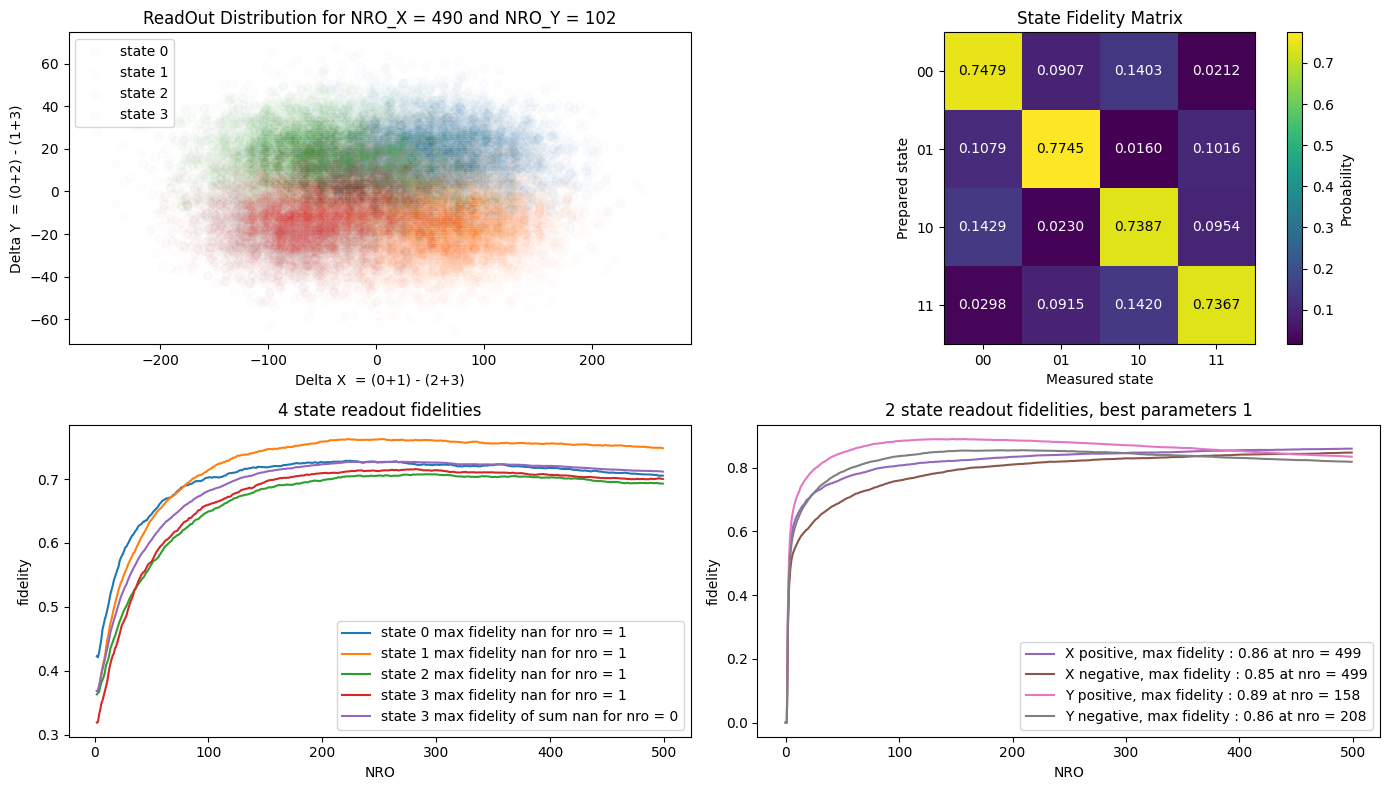

In [28]:
nro_delta_x = 490
nro_delta_y = 102
figs = []



fig,ax = plt.subplots(2,2,figsize = (14,8))

X_choosen = X_data
clicksX = X_data

nuclear_nro = X_choosen.shape[-1]



avg = X_choosen.shape[0]//4
nb_prep_states = 4
xnro = clicksX.shape[2]

print('x data shape is ',X_data.shape)  #clicks shape is  (43, 4, 50, 4)

delta_X = np.zeros((nb_prep_states,avg))
delta_X_nro = np.zeros((nb_prep_states,avg,nuclear_nro))
delta_Y_nro = np.zeros((nb_prep_states,avg,nuclear_nro))
delta_Y = np.zeros((nb_prep_states,avg))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

buffer1 =[]
buffer2 =[]
for prepped_state in [0,1,2,3]:
    
    idxs = np.where(Y_data == prepped_state)[0]
    # print('idxs = ',idxs)
    
    dx_nro = X_data[idxs,0,:] + X_data[idxs,1,:] - X_data[idxs,2,:] -X_data[idxs,3,:] 
    dy_nro = X_data[idxs,0,:] + X_data[idxs,2,:] - X_data[idxs,1,:] -X_data[idxs,3,:] 

    
    print(delta_X_nro[prepped_state].shape)
    print(dx_nro.shape)
    delta_X_nro[prepped_state] = dx_nro
    delta_Y_nro[prepped_state] = dy_nro
    delta_X[prepped_state] = dx_nro[:,nro_delta_x]
    delta_Y[prepped_state] = dy_nro[:,nro_delta_y]

    # delta_X[prepped_state,:] = np.where(np.abs(delta_X[prepped_state,:])>5,delta_X[prepped_state,:],0)
    # delta_Y[prepped_state,:] = np.where(np.abs(delta_Y[prepped_state,:])>5,delta_Y[prepped_state,:],0)

    ax[0,0].scatter(delta_X[prepped_state,:],delta_Y[prepped_state,:],label = f'state {prepped_state}',alpha = 0.01)
    

ax[0,0].set_xlabel('Delta X  = (0+1) - (2+3)')
ax[0,0].set_ylabel('Delta Y  = (0+2) - (1+3)')
ax[0,0].set_title(f'ReadOut Distribution for NRO_X = {nro_delta_x} and NRO_Y = {nro_delta_y}')
ax[0,0].legend()

states_points  = np.array([np.stack((delta_X[i], delta_Y[i]),axis= 1) for i in range(4)])
states_points_nro  = np.array([np.stack((delta_X_nro[i,:], delta_Y_nro[i,:]),axis= 1) for i in range(4)])
print("state points shape is ", states_points_nro.shape)
labels = np.zeros(states_points.shape[:2], dtype=int)-1
labels_nro = np.zeros(states_points.shape[:2], dtype=int)-1
fidelity = np.zeros((4,nuclear_nro))
for i, state  in enumerate(states_points):
    
    
    for nro in range(1,nuclear_nro):
        
        _dx = states_points_nro[i][:, 0,:nro].sum(1)
        _dy = states_points_nro[i][:, 1,:nro].sum(1)
        labels_nro[i, (_dx > 0) & (_dy > 0)] = 0
        labels_nro[i, (_dx < 0) & (_dy > 0)] = 2
        labels_nro[i, (_dx > 0) & (_dy< 0)] = 1
        labels_nro[i, (_dx < 0) & (_dy< 0)] = 3
        
        a = np.array([np.sum(labels_nro[i,:]==0),np.sum(labels_nro[i,:]==1),np.sum(labels_nro[i,:]==2),np.sum(labels_nro[i,:]==3)])
        
        fidelity[i,nro] = a[i]/np.sum(a)
        
    labels[i, (state[:, 0] > 0) & (state[:, 1] > 0)] = 0
    labels[i, (state[:, 0] < 0) & (state[:, 1] > 0)] = 2
    labels[i, (state[:, 0] > 0) & (state[:, 1] < 0)] = 1
    labels[i, (state[:, 0] < 0) & (state[:, 1] < 0)] = 3
    
    
    ax[1,0].plot(np.arange(1,nuclear_nro),fidelity[i,1:],label = f'state {i} max fidelity {np.max(fidelity[i,:]):.3f} for nro = {np.argmax(fidelity[i,:])}')
    
sum = (fidelity[0,1:] + fidelity[1,1:] + fidelity[2,1:] + fidelity[3,1:])/4
ax[1,0].plot(np.arange(1,nuclear_nro),sum,label = f'state {i} max fidelity of sum {np.max(sum):.3f} for nro = {np.argmax(sum)}')

ax[1,0].set_xlabel('NRO')
ax[1,0].set_ylabel('fidelity')
ax[1,0].set_title('4 state readout fidelities')
ax[1,0].legend()
coords = np.concatenate(states_points_nro)
x_pfidelity = []
x_nfidelity = []
y_pfidelity = []
y_nfidelity = []

fidelity_map = np.zeros((nuclear_nro,nuclear_nro))

# for nro_x in range(nuclear_nro):
#     print(nro_x)
#     for nro_y in range(nuclear_nro):
        
#         _dx = states_points_nro[:, :, 0,:nro_x].sum(2)
#         _dy = states_points_nro[:, :, 1,:nro_y].sum(2)
        
#         f0 = np.sum((_dx[0] > 0) & (_dy[0] > 0))/_dx[0].shape[0]
#         f1 =  np.sum((_dx[2] < 0) & (_dy[2] > 0))/_dx[2].shape[0]
#         f2 =  np.sum((_dx[1] > 0) & (_dy[1] < 0))/_dx[1].shape[0]
#         f3 =  np.sum((_dx[3] < 0) & (_dy[3] < 0))/_dx[3].shape[0]
        
#         fidelity_map[nro_x,nro_y] = (f0+f1+f2+f3)/4

best_nros = np.argmax(fidelity_map)+1
        
        

for nro in range(nuclear_nro):
    
    
    _dx = states_points_nro[:,:, 0,:nro].sum(-1)
    _dy = states_points_nro[:,:, 1,:nro].sum(-1)

    x_pfidelity.append((np.sum(_dx[0,:]>0) + np.sum(_dx[1,:]>0))/(_dx[0,:].shape[0]+_dx[1,:].shape[0]))
    x_nfidelity.append((np.sum(_dx[2,:]<0) + np.sum(_dx[3,:]<0))/(_dx[2,:].shape[0]+_dx[3,:].shape[0]))
    
    y_pfidelity.append((np.sum(_dy[0,:]>0) + np.sum(_dy[2,:]>0))/(_dy[0,:].shape[0]+_dy[2,:].shape[0]))
    y_nfidelity.append((np.sum(_dy[1,:]<0) + np.sum(_dy[3,:]<0))/(_dy[1,:].shape[0]+_dy[3,:].shape[0]))
    

ax[1,1].plot(np.arange(nuclear_nro),x_pfidelity, label = f'X positive, max fidelity : {np.max(x_pfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(x_pfidelity)]+1}',color = colors[4])
ax[1,1].plot(np.arange(nuclear_nro),x_nfidelity, label = f'X negative, max fidelity : {np.max(x_nfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(x_nfidelity)]+1}',color = colors[5])
ax[1,1].plot(np.arange(nuclear_nro),y_pfidelity, label = f'Y positive, max fidelity : {np.max(y_pfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(y_pfidelity)]+1}',color = colors[6])
ax[1,1].plot(np.arange(nuclear_nro),y_nfidelity, label = f'Y negative, max fidelity : {np.max(y_nfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(y_nfidelity)]+1}',color = colors[7])
ax[1,1].set_xlabel('NRO')
ax[1,1].set_ylabel('fidelity')
ax[1,1].set_title(f'2 state readout fidelities, best parameters {best_nros}')
ax[1,1].legend()


Plot_State_prep_matrix2(labels,ax[0,1])
ax[0,1].set_title('State Fidelity Matrix')
fig.tight_layout()
plt.show()

# get simulated Data

## Gaussian distributed 

In [ ]:
Nb_sims = 100_000
nro = 500

dark_rate=  np.random.normal(0.17,0.05,Nb_sims)
dark_rate = np.clip(dark_rate, 0.001, 0.5)

signal_rate= np.random.normal(0.16,0.5,Nb_sims)
signal_rate = np.clip(signal_rate, 0.001, 0.5)

a=  1879 * np.ones(Nb_sims)

b =  a*10* np.ones(Nb_sims)

probs = np.array([1-1/a-1/b,1/a,1/b])

X_data_sim = np.array([get_trace(nro,init_state = k%4,signal_rate = signal_rate[k],dark_rate=dark_rate[k],probs = probs[:,k]) for k in range(Nb_sims)])
Y_data_sim = np.array([k%4 for k in range(Nb_sims)])

## equally distributed 

In [29]:
Nb_sims = 10_000
nro = 500

dark_rate = np.random.uniform(0.19, 0.19, Nb_sims)
signal_rate = np.random.uniform(0.18, 0.16, Nb_sims)

a = np.random.uniform(100, 1000, Nb_sims)
b = np.random.uniform(1000, 6000, Nb_sims)

a=  1879 * np.ones(Nb_sims)

b =  a*10* np.ones(Nb_sims)

probs = np.array([1 - 1/a - 1/b, 1/a, 1/b])

X_data_sim = np.array([get_trace(nro,init_state = k%4,signal_rate = signal_rate[k],dark_rate=dark_rate[k],probs = probs[:,k]) for k in range(Nb_sims)])
Y_data_sim = np.array([k%4 for k in range(Nb_sims)])

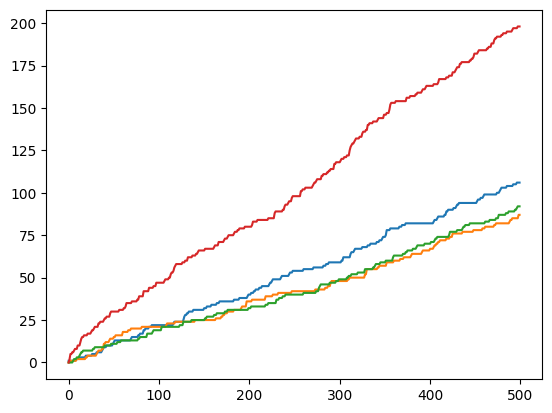

In [662]:
i = np.random.choice(np.arange(Nb_sims))

plt.plot(X_data_sim[i,0,:])
plt.plot(X_data_sim[i,1,:])
plt.plot(X_data_sim[i,2,:])
plt.plot(X_data_sim[i,3,:])



# Plot simulated with real data 

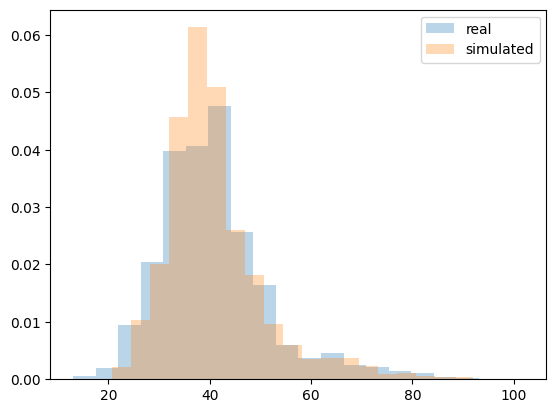

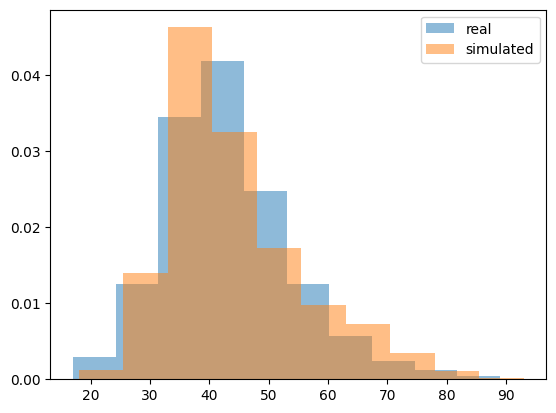

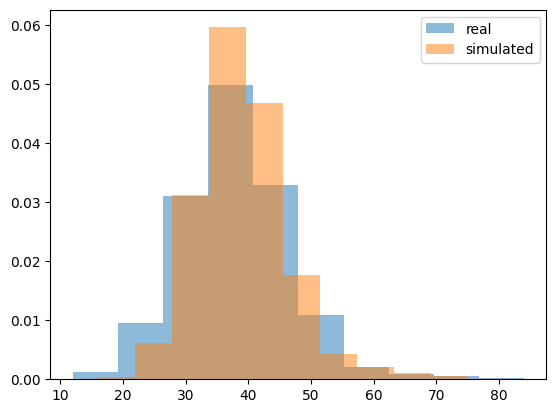

In [324]:
nro = 200


plt.hist(X_data[Y_data ==0,2,nro],density=True,label = 'real',alpha = 0.3,bins = 20)
plt.hist(X_data_sim[Y_data_sim ==0,2,nro],density=True,label = 'simulated',alpha = 0.3,bins = 20)
plt.legend()

plt.figure()
plt.hist(X_data[Y_data ==1,0,nro],density=True,label = 'real',alpha = 0.5)
plt.hist(X_data_sim[Y_data_sim ==1,0,nro],density=True,label = 'simulated',alpha = 0.5)
plt.legend()


plt.figure()
plt.hist(X_data[Y_data ==0,3,nro],density=True,label = 'real',alpha = 0.5)
plt.hist(X_data_sim[Y_data_sim ==0,3,nro],density=True,label = 'simulated',alpha = 0.5)
plt.legend()


# Generate the datasets 

In [ ]:
X_data_sim.shape

(50000, 4, 500)

In [663]:

# split
X_train_real, X_test_real, Y_train_real, Y_test_real = train_test_split(
    X_data, Y_data, test_size=0.9, random_state=42, stratify=Y_data
)

X_train_sim, X_test_sim, Y_train_sim, Y_test_sim = train_test_split(
    X_data_sim, Y_data_sim, test_size=0.9, random_state=42, stratify=Y_data_sim
)


# X_train = X_train_real
# Y_train = Y_train_real
X_train = np.concatenate((X_train_real,X_data_sim))
Y_train = np.concatenate((Y_train_real,Y_data_sim))

# datasets
train_sim_dataset = ReadoutDataset_Fancy_(X_train, Y_train)
test_real_dataset = ReadoutDataset_Fancy_(X_test_real, Y_test_real)
test_sim_dataset = ReadoutDataset_Fancy_(X_test_sim, Y_test_sim)
batch_size = 250
# loaders
train_loader = DataLoader(train_sim_dataset, batch_size=batch_size, shuffle=True)
test_real_loader = DataLoader(test_real_dataset, batch_size=200, shuffle=True)
test_sim_loader = DataLoader(test_sim_dataset, batch_size=1000, shuffle=True)

# Training 

In [599]:
for x_batch, y_batch in test_real_loader:
    print(x_batch.shape)

torch.Size([200, 9, 49])
torch.Size([200, 9, 49])
torch.Size([200, 9, 49])
torch.Size([48, 9, 49])


In [642]:
train_losses = []
test_real_losses = []
test_sim_losses = []

train_accs = []
test_sim_accs = []
test_real_accs = []

model = ReadoutNet(bins = 49)
learning_rate = 0.1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

n_epochs = 20000

for epoch in range(n_epochs):
    # -----------------
    # training
    # -----------------
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x_batch, y_batch in train_loader:
        logits,pred = model(x_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(y_batch)
        train_correct += (pred == y_batch).sum().item()
        train_total += len(y_batch)

    train_loss /= train_total
    train_acc = train_correct / train_total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # -----------------
    # testing
    # -----------------
    model.eval()
    test_real_loss ,test_sim_loss = 0,0
    test_real_correct , test_sim_correct = 0,0
    test_real_total,test_sim_total = 0,0

    with torch.no_grad():
        for x_batch, y_batch in test_real_loader:
            logits, pred = model(x_batch)
            loss = criterion(logits, y_batch)

            test_real_loss += loss.item() * len(y_batch)
            test_real_correct += (pred == y_batch).sum().item()
            test_real_total += len(y_batch)

        test_real_loss /= test_real_total
        test_real_acc = test_real_correct / test_real_total

        test_real_losses.append(test_real_loss)
        test_real_accs.append(test_real_acc)
            
        for x_batch, y_batch in test_sim_loader:
            logits, pred = model(x_batch)
            loss = criterion(logits, y_batch)

            test_sim_loss += loss.item() * len(y_batch)
            test_sim_correct += (pred == y_batch).sum().item()
            test_sim_total += len(y_batch)

        test_sim_loss /= test_sim_total
        test_sim_acc = test_sim_correct / test_sim_total

        test_sim_losses.append(test_sim_loss)
        test_sim_accs.append(test_sim_acc)

    print(
        f"epoch {epoch+1:02d} | "
        f"train loss {train_loss:.4f} acc {100*train_acc:.2f}% | "
        f"test sim loss {test_sim_loss:.4f} acc {100*test_sim_acc:.2f}% | "
        f"test real loss {test_real_loss:.4f} acc {100*test_real_acc:.2f}"
    )



epoch 01 | train loss 1.3772 acc 28.63% | test sim loss 1.3530 acc 37.74% | test real loss 1.3537 acc 35.49
epoch 02 | train loss 1.3312 acc 41.62% | test sim loss 1.3053 acc 50.42% | test real loss 1.3100 acc 45.37
epoch 03 | train loss 1.2838 acc 61.37% | test sim loss 1.2571 acc 70.62% | test real loss 1.2672 acc 59.26
epoch 04 | train loss 1.2360 acc 74.46% | test sim loss 1.2089 acc 78.01% | test real loss 1.2251 acc 66.67
epoch 05 | train loss 1.1881 acc 77.00% | test sim loss 1.1604 acc 79.14% | test real loss 1.1837 acc 68.06
epoch 06 | train loss 1.1403 acc 78.41% | test sim loss 1.1122 acc 79.39% | test real loss 1.1427 acc 68.98
epoch 07 | train loss 1.0932 acc 78.43% | test sim loss 1.0652 acc 79.72% | test real loss 1.1035 acc 69.44
epoch 08 | train loss 1.0472 acc 78.95% | test sim loss 1.0196 acc 79.93% | test real loss 1.0658 acc 70.06
epoch 09 | train loss 1.0028 acc 79.14% | test sim loss 0.9755 acc 80.02% | test real loss 1.0299 acc 70.22
epoch 10 | train loss 0.9602

KeyboardInterrupt: 

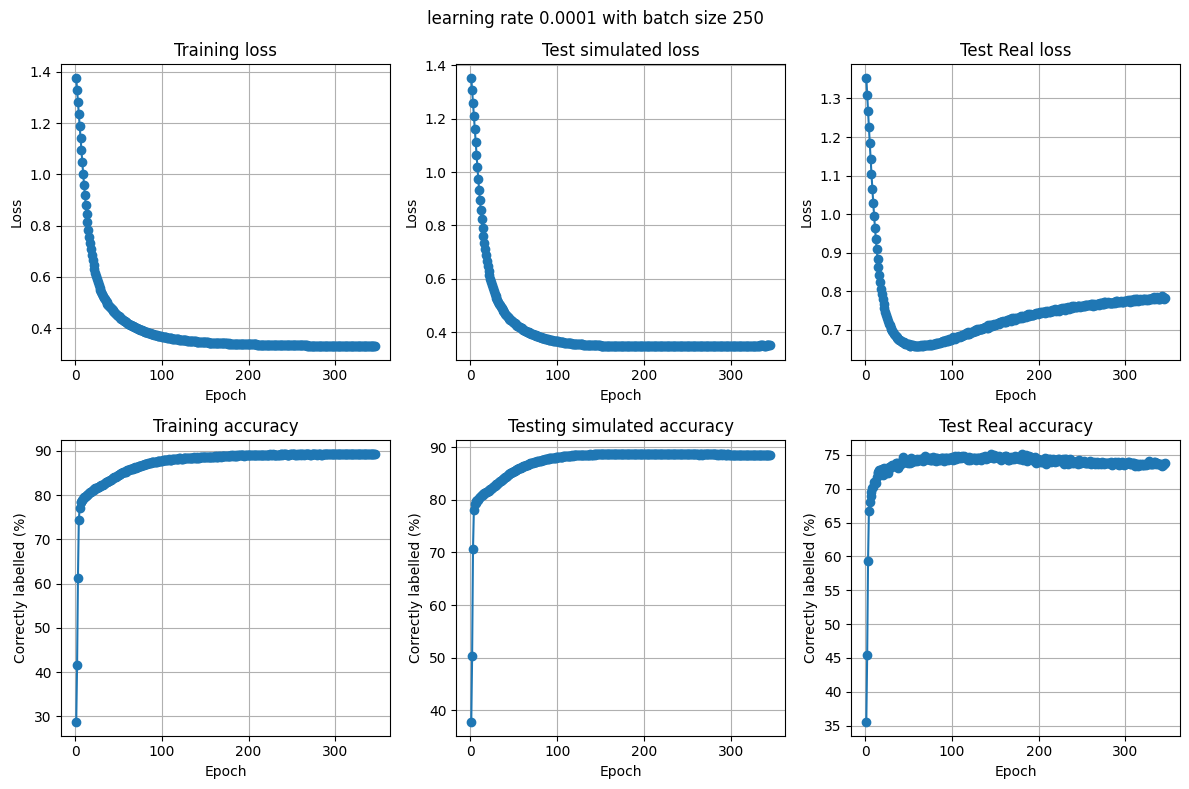

In [643]:
# -----------------
# plots
# -----------------
fig, ax = plt.subplots(2, 3, figsize=(12, 8))

epochs = range(1, len(train_losses) + 1)


ax[0, 0].plot(epochs, train_losses, marker='o')
ax[0, 0].set_title("Training loss")
ax[0, 0].set_xlabel("Epoch")
ax[0, 0].set_ylabel("Loss")
ax[0, 0].grid(True)

epochs = range(1, len(test_sim_losses) +1)

ax[0, 1].plot(epochs, test_sim_losses, marker='o')
ax[0, 1].set_title("Test simulated loss")
ax[0, 1].set_xlabel("Epoch")
ax[0, 1].set_ylabel("Loss")
ax[0, 1].grid(True)

epochs = range(1, len(test_real_losses) +1)

ax[0, 2].plot(epochs, test_real_losses, marker='o')
ax[0, 2].set_title("Test Real loss")
ax[0, 2].set_xlabel("Epoch")
ax[0, 2].set_ylabel("Loss")
ax[0, 2].grid(True)

epochs = range(1, len(100 * torch.tensor(train_accs)) +1)

ax[1, 0].plot(epochs, 100 * torch.tensor(train_accs), marker='o')
ax[1, 0].set_title("Training accuracy")
ax[1, 0].set_xlabel("Epoch")
ax[1, 0].set_ylabel("Correctly labelled (%)")
ax[1, 0].grid(True)

epochs = range(1, len( 100 * torch.tensor(test_sim_accs)) +1)


ax[1, 1].plot(epochs, 100 * torch.tensor(test_sim_accs), marker='o')
ax[1, 1].set_title("Testing simulated accuracy")
ax[1, 1].set_xlabel("Epoch")
ax[1, 1].set_ylabel("Correctly labelled (%)")
ax[1, 1].grid(True)

epochs = range(1, len( 100 * torch.tensor(test_real_accs)) +1)

ax[1, 2].plot(epochs, 100 * torch.tensor(test_real_accs), marker='o')
ax[1, 2].set_title("Test Real accuracy")
ax[1, 2].set_xlabel("Epoch")
ax[1, 2].set_ylabel("Correctly labelled (%)")
ax[1, 2].grid(True)

plt.suptitle(f'learning rate {learning_rate} with batch size {batch_size}')
plt.tight_layout()
plt.show()

# Saving   

In [360]:
save_model_with_accuracy(model,test_real_acc,'Best so far')

saved Best so farmodel_acc_0.7769.pt


# Simple testing

In [ ]:
class ReadoutNet2(nn.Module):
    def __init__(self,nro):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(4*nro, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        # x: (batch, 4, 300)
        x = x.view(x.shape[0], -1)

        logits = self.net(x)
        pred = torch.argmax(logits, dim=1)

        return logits, pred
    
model = ReadoutNet2(500)

In [ ]:
denom = torch.arange(1, X_data.shape[-1]+1, dtype=torch.float32).view(1, 1, 500)
torch.tensor(X_data[a]).unsqueeze(0)

tensor([[[  0,   1,   1,  ...,  73,  73,  73],
         [  0,   1,   3,  ..., 103, 103, 103],
         [  0,   0,   0,  ...,  81,  81,  82],
         [  0,   1,   2,  ..., 137, 137, 137]]])

In [ ]:
torch.arange(1, X_data.shape[-1]+1, dtype=torch.float32).view(1, 1, 500).shape

torch.Size([1, 1, 500])

In [ ]:
model(torch.tensor(X_data[a] , dtype=torch.float32).unsqueeze(0).contiguous())

(tensor([[ 0.6218,  0.4480,  1.8869, -2.5076]], grad_fn=<AddmmBackward0>),
 tensor([2]))

631


Text(0, 0.5, 'counts')

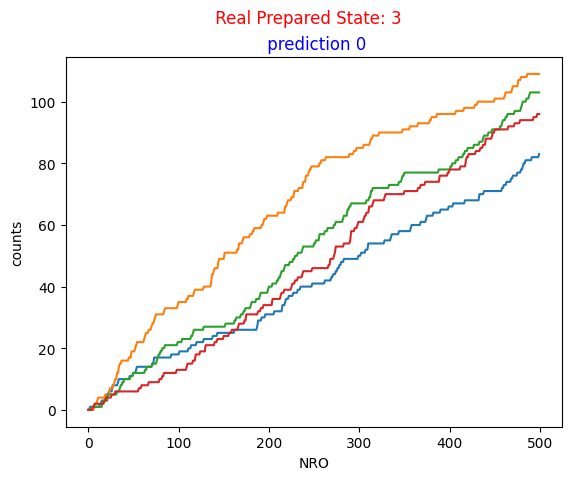

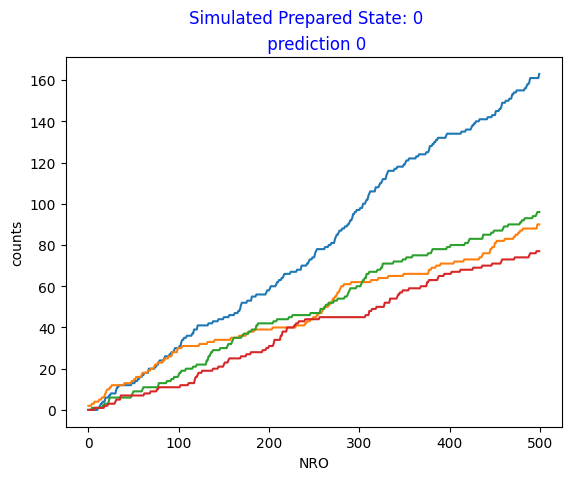

In [494]:

colors = ['blue','orange','green','red']

a = np.random.choice(np.arange(Y_data.shape[0]))
b = np.random.choice(np.arange(Y_data_sim.shape[0]))

print(a)
model.eval()
with torch.no_grad():
    denom = torch.arange(1, X_data.shape[-1]+1, dtype=torch.float32).view(1, 1, 500)
    out_real,pred_real = model(torch.tensor(X_data[a]).unsqueeze(0).contiguous()/denom)
    out_sim,pred_sim = model(torch.tensor(X_data_sim[b]).unsqueeze(0)/denom)

for i in range(4):
    plt.plot(X_data[a,i,:])
plt.suptitle(f' Real Prepared State: {Y_data[a]}', color = colors[Y_data[a]])
plt.title(f' prediction {pred_real.item()}', color = colors[pred_real])
plt.xlabel('NRO')
plt.ylabel('counts')

plt.figure()
for i in range(4):
    plt.plot(X_data_sim[b,i,:])
plt.suptitle(f'Simulated Prepared State: {Y_data_sim[b]}', color = colors[Y_data_sim[b]])
plt.title(f' prediction {pred_sim.item()}', color = colors[pred_sim])
plt.xlabel('NRO')
plt.ylabel('counts')

In [ ]:
correct = 0
false = 0

for a in range(X_data_real.shape[0]):

    model.eval()
    with torch.no_grad():
        denom = torch.arange(1, 701, dtype=torch.float32).view(1, 1, 700)
        out,pred = model(torch.tensor(X_data_sim[a]).unsqueeze(0)/denom)

    if pred.item() == Y_data_sim[a]:
        correct+=1
        
        
print('fidelity is ', correct/X_data_sim.shape[0])

NameError: name 'X_data_real' is not defined

In [ ]:
X_data.shape

(720, 4, 500)

# Get Fidelity Matrix

# Using Dx DY

In [27]:
def Plot_State_prep_matrix2(labels,ax):
    
    state_matrix = np.zeros((4, 4))

    for i in range(4):
        for j in range(4):
            state_matrix[i, j] = (labels[i]==j).sum(0)/np.sum((labels[i]==0) | (labels[i]==1) | (labels[i]==2) | (labels[i]==3))
                
    labels = ['00', '01', '10', '11']  # adjust if different ordering

    im = ax.imshow(state_matrix)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Probability")

    # Axis ticks and labels
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    ax.set_xlabel("Measured state")
    ax.set_ylabel("Prepared state")

    # Annotate values inside squares
    for i in range(state_matrix.shape[0]):
        for j in range(state_matrix.shape[1]):
            value = state_matrix[i, j]
            ax.text(j, i,
            f"{value:.4f}",
                        ha="center",
                        va="center",
                        color="white" if value < 0.5 else "black")

    ax.set_aspect("equal")

clicks shape is  (433, 4, 700, 4)
state points shape is  (4, 433, 2, 700)


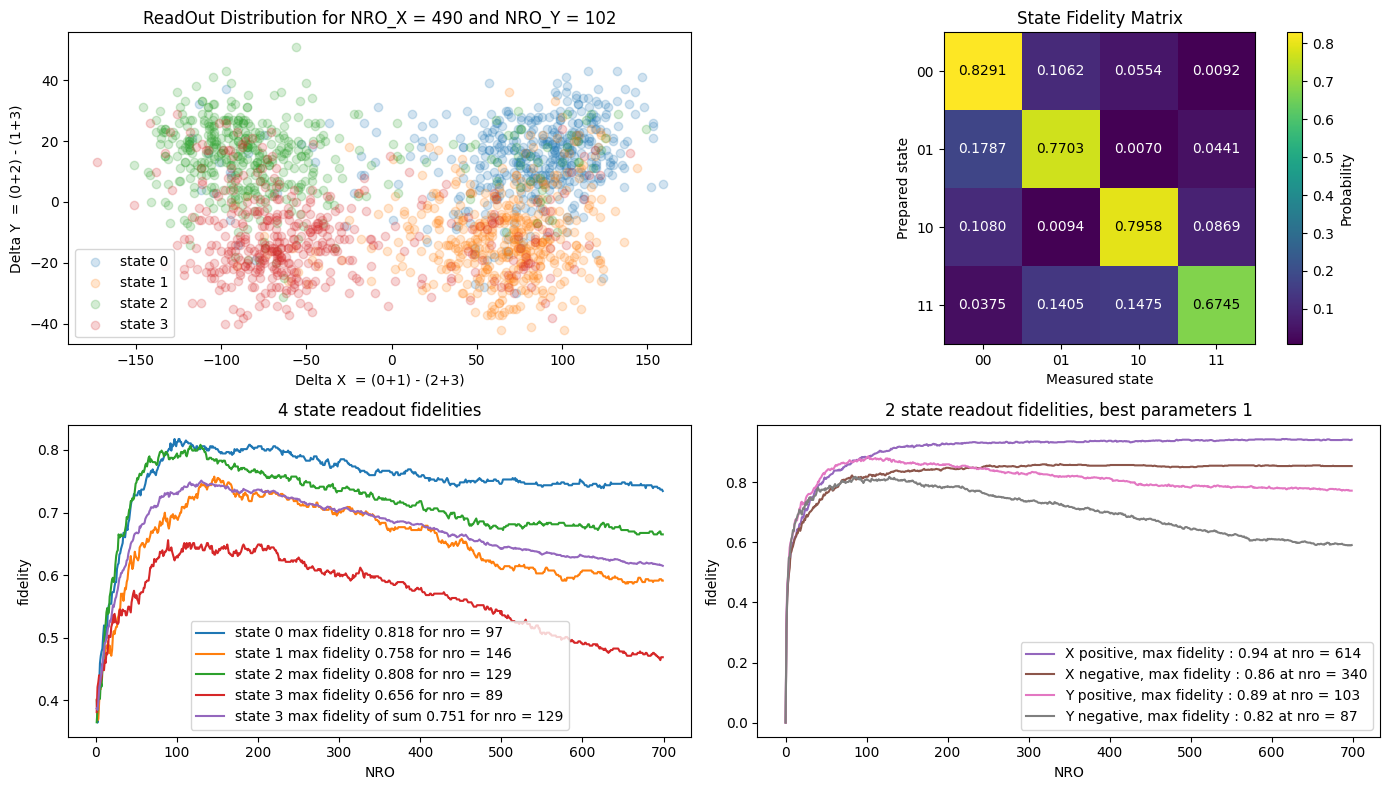

In [ ]:
nro_delta_x = 490
nro_delta_y = 102
figs = []



fig,ax = plt.subplots(2,2,figsize = (14,8))


clicksX = signal['clicksX']

nuclear_nro = clicksX.shape[2]



avg = clicksX.shape[0]
nb_prep_states = clicksX.shape[1]
xnro = clicksX.shape[2]

print('clicks shape is ',clicksX.shape)  #clicks shape is  (43, 4, 50, 4)

delta_X = np.zeros((nb_prep_states,avg))
delta_X_nro = np.zeros((nb_prep_states,avg,nuclear_nro))
delta_Y_nro = np.zeros((nb_prep_states,avg,nuclear_nro))
delta_Y = np.zeros((nb_prep_states,avg))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

buffer1 =[]
buffer2 =[]
for prepped_state in [0,1,2,3]:
    
    
    dx_nro = clicksX[:,prepped_state,:,0] + clicksX[:,prepped_state,:,1] - clicksX[:,prepped_state,:,2] - clicksX[:,prepped_state,:,3]
    dy_nro = clicksX[:,prepped_state,:,0] + clicksX[:,prepped_state,:,2] - clicksX[:,prepped_state,:,3] - clicksX[:,prepped_state,:,1]

    delta_X_nro[prepped_state] = dx_nro
    delta_Y_nro[prepped_state] = dy_nro
    delta_X[prepped_state] = dx_nro[:,:nro_delta_x].sum(1)
    delta_Y[prepped_state] = dy_nro[:,:nro_delta_y].sum(1)

    # delta_X[prepped_state,:] = np.where(np.abs(delta_X[prepped_state,:])>5,delta_X[prepped_state,:],0)
    # delta_Y[prepped_state,:] = np.where(np.abs(delta_Y[prepped_state,:])>5,delta_Y[prepped_state,:],0)

    ax[0,0].scatter(delta_X[prepped_state,:],delta_Y[prepped_state,:],label = f'state {prepped_state}',alpha = 0.2)
    

ax[0,0].set_xlabel('Delta X  = (0+1) - (2+3)')
ax[0,0].set_ylabel('Delta Y  = (0+2) - (1+3)')
ax[0,0].set_title(f'ReadOut Distribution for NRO_X = {nro_delta_x} and NRO_Y = {nro_delta_y}')
ax[0,0].legend()

states_points  = np.array([np.stack((delta_X[i], delta_Y[i]),axis= 1) for i in range(4)])
states_points_nro  = np.array([np.stack((delta_X_nro[i,:], delta_Y_nro[i,:]),axis= 1) for i in range(4)])
print("state points shape is ", states_points_nro.shape)
labels = np.zeros(states_points.shape[:2], dtype=int)-1
labels_nro = np.zeros(states_points.shape[:2], dtype=int)-1
fidelity = np.zeros((4,nuclear_nro))
for i, state  in enumerate(states_points):
    
    
    for nro in range(1,nuclear_nro):
        
        _dx = states_points_nro[i][:, 0,:nro].sum(1)
        _dy = states_points_nro[i][:, 1,:nro].sum(1)
        labels_nro[i, (_dx > 0) & (_dy > 0)] = 0
        labels_nro[i, (_dx < 0) & (_dy > 0)] = 2
        labels_nro[i, (_dx > 0) & (_dy< 0)] = 1
        labels_nro[i, (_dx < 0) & (_dy< 0)] = 3
        
        a = np.array([np.sum(labels_nro[i,:]==0),np.sum(labels_nro[i,:]==1),np.sum(labels_nro[i,:]==2),np.sum(labels_nro[i,:]==3)])
        
        fidelity[i,nro] = a[i]/np.sum(a)
        
    labels[i, (state[:, 0] > 0) & (state[:, 1] > 0)] = 0
    labels[i, (state[:, 0] < 0) & (state[:, 1] > 0)] = 2
    labels[i, (state[:, 0] > 0) & (state[:, 1] < 0)] = 1
    labels[i, (state[:, 0] < 0) & (state[:, 1] < 0)] = 3
    
    
    ax[1,0].plot(np.arange(1,nuclear_nro),fidelity[i,1:],label = f'state {i} max fidelity {np.max(fidelity[i,:]):.3f} for nro = {np.argmax(fidelity[i,:])}')
    
sum = (fidelity[0,1:] + fidelity[1,1:] + fidelity[2,1:] + fidelity[3,1:])/4
ax[1,0].plot(np.arange(1,nuclear_nro),sum,label = f'state {i} max fidelity of sum {np.max(sum):.3f} for nro = {np.argmax(sum)}')

ax[1,0].set_xlabel('NRO')
ax[1,0].set_ylabel('fidelity')
ax[1,0].set_title('4 state readout fidelities')
ax[1,0].legend()
coords = np.concatenate(states_points_nro)
x_pfidelity = []
x_nfidelity = []
y_pfidelity = []
y_nfidelity = []

fidelity_map = np.zeros((nuclear_nro,nuclear_nro))

# for nro_x in range(nuclear_nro):
#     print(nro_x)
#     for nro_y in range(nuclear_nro):
        
#         _dx = states_points_nro[:, :, 0,:nro_x].sum(2)
#         _dy = states_points_nro[:, :, 1,:nro_y].sum(2)
        
#         f0 = np.sum((_dx[0] > 0) & (_dy[0] > 0))/_dx[0].shape[0]
#         f1 =  np.sum((_dx[2] < 0) & (_dy[2] > 0))/_dx[2].shape[0]
#         f2 =  np.sum((_dx[1] > 0) & (_dy[1] < 0))/_dx[1].shape[0]
#         f3 =  np.sum((_dx[3] < 0) & (_dy[3] < 0))/_dx[3].shape[0]
        
#         fidelity_map[nro_x,nro_y] = (f0+f1+f2+f3)/4

best_nros = np.argmax(fidelity_map)+1
        
        

for nro in range(nuclear_nro):
    
    
    _dx = states_points_nro[:,:, 0,:nro].sum(-1)
    _dy = states_points_nro[:,:, 1,:nro].sum(-1)

    x_pfidelity.append((np.sum(_dx[0,:]>0) + np.sum(_dx[1,:]>0))/(_dx[0,:].shape[0]+_dx[1,:].shape[0]))
    x_nfidelity.append((np.sum(_dx[2,:]<0) + np.sum(_dx[3,:]<0))/(_dx[2,:].shape[0]+_dx[3,:].shape[0]))
    
    y_pfidelity.append((np.sum(_dy[0,:]>0) + np.sum(_dy[2,:]>0))/(_dy[0,:].shape[0]+_dy[2,:].shape[0]))
    y_nfidelity.append((np.sum(_dy[1,:]<0) + np.sum(_dy[3,:]<0))/(_dy[1,:].shape[0]+_dy[3,:].shape[0]))
    

ax[1,1].plot(np.arange(nuclear_nro),x_pfidelity, label = f'X positive, max fidelity : {np.max(x_pfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(x_pfidelity)]+1}',color = colors[4])
ax[1,1].plot(np.arange(nuclear_nro),x_nfidelity, label = f'X negative, max fidelity : {np.max(x_nfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(x_nfidelity)]+1}',color = colors[5])
ax[1,1].plot(np.arange(nuclear_nro),y_pfidelity, label = f'Y positive, max fidelity : {np.max(y_pfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(y_pfidelity)]+1}',color = colors[6])
ax[1,1].plot(np.arange(nuclear_nro),y_nfidelity, label = f'Y negative, max fidelity : {np.max(y_nfidelity):.2f} at nro = {np.arange(nuclear_nro)[np.argmax(y_nfidelity)]+1}',color = colors[7])
ax[1,1].set_xlabel('NRO')
ax[1,1].set_ylabel('fidelity')
ax[1,1].set_title(f'2 state readout fidelities, best parameters {best_nros}')
ax[1,1].legend()


Plot_State_prep_matrix2(labels,ax[0,1])
ax[0,1].set_title('State Fidelity Matrix')
fig.tight_layout()
plt.show()

In [ ]:
X_data = X_data.transpose(0,2,1)

In [ ]:
signal['clicksX'].shape

(180, 4, 500, 4)

# Using Model 

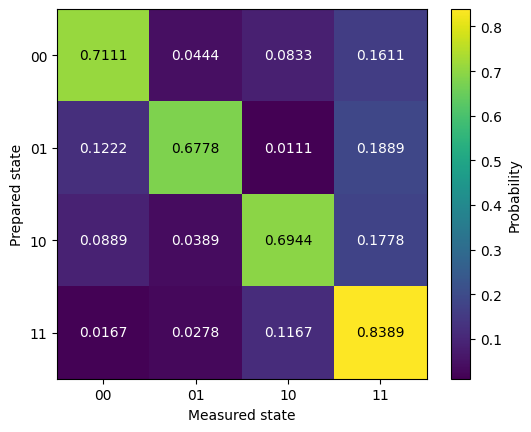

In [362]:
nro_delta_y = 120
nro_delta_x = 400


prepared_states = []
model.eval()
with torch.no_grad():
    for prepared_state in [0,1,2,3]:
        
        read_outs = np.zeros(len(np.where(Y_data == prepared_state)[0]))
        
        for c,i in enumerate(np.where(Y_data == prepared_state)[0]):
            
            denom = torch.arange(1, 500+1, dtype=torch.float32).view(1,1,  500)
            x = torch.tensor(X_data[i, :, :500], dtype=torch.float32).unsqueeze(0)
            x = (x / denom).contiguous()
            out_real,pred_real = model(x)
            # print(pred_real)
            
            read_outs[c] = pred_real.item()
        
        
        prepared_states.append(read_outs)
            
            
            
state_matrix = np.zeros((4,4))
    
for prepped_state in range(4):
    for ro_state in range(4):
        state_matrix[prepped_state,ro_state] = np.sum(prepared_states[prepped_state] == ro_state)/prepared_states[prepped_state].shape[0]
    
     
        
fig,ax = plt.subplots()       
im = ax.imshow(state_matrix)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Probability")
labels = ['00', '01', '10', '11']  # adjust if different ordering

# Axis ticks and labels
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

ax.set_xlabel("Measured state")
ax.set_ylabel("Prepared state")

# Annotate values inside squares
for i in range(state_matrix.shape[0]):
    for j in range(state_matrix.shape[1]):
        value = state_matrix[i, j]
        ax.text(j, i,
        f"{value:.4f}",
                    ha="center",
                    va="center",
                    color="white" if value < 0.5 else "black")

ax.set_aspect("equal")


In [ ]:
(torch.tensor(X_data[i,:,:300]).unsqueeze(0)/denom).shape
# model(torch.tensor(X_data[i,:,:300]).unsqueeze(0)/denom)

torch.Size([1, 4, 300])

# doing fancy stuff

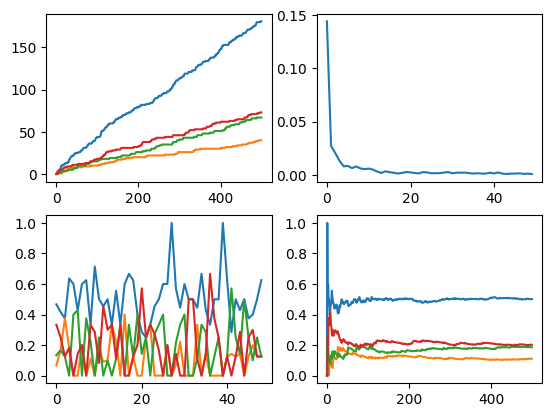

In [569]:
x = X_data[0]          # shape (4, N)
bin_size = 10

total_clicks = x.sum(0, keepdims=True)
safe_total_clicks = np.where(total_clicks == 0, 1, total_clicks)
est = x / safe_total_clicks
gradients = np.diff(x, axis=1)

N = est.shape[1]
N_grad = gradients.shape[1]

n_bins = N // bin_size
n_bins_grad = N_grad // bin_size

est_trimmed = est[:, :n_bins * bin_size]
grads_trimmed = gradients[:, :n_bins_grad * bin_size]

est_binned = est_trimmed.reshape(4, n_bins, bin_size)
grads_binned = grads_trimmed.reshape(4, n_bins_grad, bin_size).mean(-1)

# normalize gradients so the 4 curves sum to 1 in each bin
grad_sum = grads_binned.sum(axis=0, keepdims=True)
safe_grad_sum = np.where(grad_sum == 0, 1, grad_sum)
grads_binned_norm = grads_binned / safe_grad_sum

std = []
for bin_i in range(n_bins):
    pieces = []
    for curve_i in range(4):
        this_bin = est_binned[curve_i, bin_i, :]
        pieces.append(this_bin - this_bin.mean())
    concat = np.concatenate(pieces)
    std.append(np.std(concat))

std = np.array(std)

fig, axs = plt.subplots(2, 2)

axs[0, 1].plot(std)

for i in range(4):
    axs[0, 0].plot(x[i])
    axs[1, 0].plot(grads_binned_norm[i])
    axs[1, 1].plot(est[i])

plt.show()

In [572]:
def make_features(x, bin_size=10):
    """
    Parameters
    ----------
    x : array, shape (4, N)
        Four accumulated-count curves.
    bin_size : int
        Bin width.

    Returns
    -------
    features : array, shape (9, n_bins)
        Row 0..3 : binned estimators
        Row 4..7 : binned normalized gradients
        Row 8    : std per bin
    """
    x = np.asarray(x, dtype=float)

    if x.shape[0] != 4:
        raise ValueError(f"Expected shape (4, N), got {x.shape}")

    # ----- estimator -----
    total_clicks = x.sum(axis=0, keepdims=True)
    safe_total_clicks = np.where(total_clicks == 0, 1, total_clicks)
    est = x / safe_total_clicks

    # ----- gradients -----
    gradients = np.diff(x, axis=1)

    # use a common number of bins for both estimator and gradients
    n_bins = min(est.shape[1] // bin_size, gradients.shape[1] // bin_size)

    est_trimmed = est[:, :n_bins * bin_size]
    grads_trimmed = gradients[:, :n_bins * bin_size]

    est_binned = est_trimmed.reshape(4, n_bins, bin_size).mean(axis=2)
    grads_binned = grads_trimmed.reshape(4, n_bins, bin_size).mean(axis=2)

    # normalize gradients so that for each bin the 4 gradients sum to 1
    grad_sum = grads_binned.sum(axis=0, keepdims=True)
    safe_grad_sum = np.where(grad_sum == 0, 1, grad_sum)
    grads_binned_norm = grads_binned / safe_grad_sum

    # ----- std per bin -----
    est_binned_full = est_trimmed.reshape(4, n_bins, bin_size)

    std = []
    for bin_i in range(n_bins):
        pieces = []
        for curve_i in range(4):
            this_bin = est_binned_full[curve_i, bin_i, :]
            pieces.append(this_bin - this_bin.mean())
        concat = np.concatenate(pieces)
        std.append(np.std(concat))
    std = np.array(std)[None, :]   # shape (1, n_bins)

    # ----- concatenate into (9, n_bins) -----
    features = np.concatenate([est_binned, grads_binned_norm, std], axis=0)

    return features

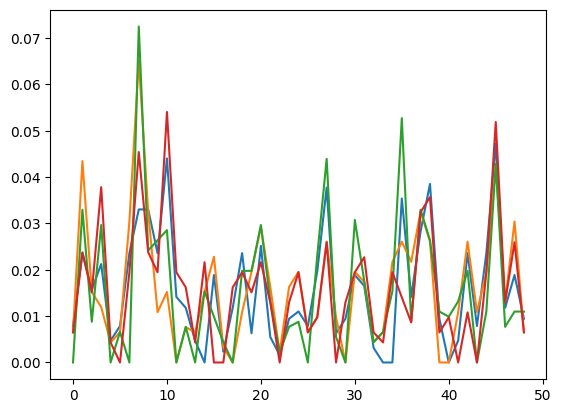

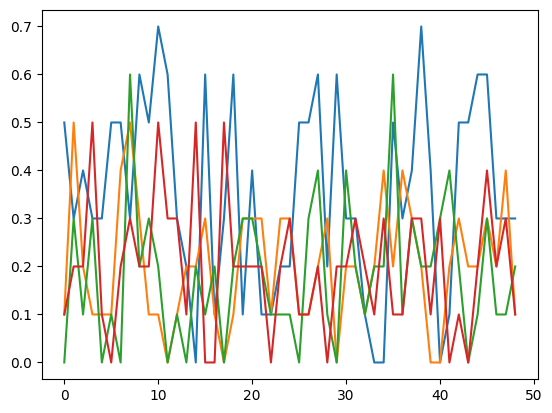

In [ ]:
def shape_X(x):
    nro_list = np.arange(1,x.shape[1]+1).repeat(4)
    est = 